# SORT Tracker - Optuna Hyperparameter Search Analysis

This notebook analyzes the hyperparameter optimization results for the SORT tracker.
We explore the relationship between hyperparameters (`max_age`, `min_hits`, `iou_threshold`) and the tracking metrics (HOTA, IDF1).

In [36]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Data from Optuna Database

In [37]:
# Connect to Optuna database
DB_PATH = "../results/studies/optimization.db"
STUDY_NAME = "sort_params_study"

conn = sqlite3.connect(DB_PATH)

# Check available studies
studies = pd.read_sql("SELECT * FROM studies;", conn)
print("Available studies:")
print(studies)
print("\n" + "="*80)

Available studies:
   study_id                    study_name
0         1             sort_params_study
1         2        bytetrack_params_study
2         4           ocsort_params_study
3         5              iou_params_study
4         6  iou_params_study_grid_search



In [38]:
# Load trials for our study
query_trials = f"""
SELECT * FROM trials 
WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
"""
df_trials = pd.read_sql(query_trials, conn)

# Load trial parameters
query_params = f"""
SELECT * FROM trial_params 
WHERE trial_id IN (
    SELECT trial_id FROM trials 
    WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
)
"""
df_params = pd.read_sql(query_params, conn)

# Load trial values (multi-objective: HOTA and IDF1)
query_values = f"""
SELECT * FROM trial_values 
WHERE trial_id IN (
    SELECT trial_id FROM trials 
    WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
)
"""
df_values = pd.read_sql(query_values, conn)

conn.close()

print(f"Total trials: {len(df_trials)}")
print(f"Total parameters: {len(df_params)}")
print(f"Total values: {len(df_values)}")

Total trials: 552
Total parameters: 1656
Total values: 1088


## 2. Prepare Data

In [39]:
# Pivot parameters to have one column per parameter
df_params_pivot = df_params.pivot(
    index="trial_id",
    columns="param_name",
    values="param_value"
).reset_index()
df_params_pivot.columns.name = None

# Check df_values structure
print("df_values columns:", df_values.columns.tolist())
print("\ndf_values sample:")
print(df_values.head(10))

# Pivot values to have HOTA and IDF1 as separate columns
if 'objective_id' in df_values.columns:
    df_hota = df_values[df_values['objective_id'] == 0][['trial_id', 'value']].rename(columns={'value': 'HOTA'})
    df_idf1 = df_values[df_values['objective_id'] == 1][['trial_id', 'value']].rename(columns={'value': 'IDF1'})
else:
    print("\nProcessing multi-objective values without objective_id...")
    df_values_sorted = df_values.sort_values('trial_id')
    
    hota_data = []
    idf1_data = []
    
    for trial_id in df_values_sorted['trial_id'].unique():
        trial_values = df_values_sorted[df_values_sorted['trial_id'] == trial_id]['value'].values
        if len(trial_values) >= 2:
            hota_data.append({'trial_id': trial_id, 'HOTA': trial_values[0]})
            idf1_data.append({'trial_id': trial_id, 'IDF1': trial_values[1]})
    
    df_hota = pd.DataFrame(hota_data)
    df_idf1 = pd.DataFrame(idf1_data)
    
    print(f"Extracted {len(df_hota)} HOTA values and {len(df_idf1)} IDF1 values")

print("\n" + "="*80)

# Merge everything
df_results = df_params_pivot.merge(df_hota, on='trial_id').merge(df_idf1, on='trial_id')

# Convert to numeric
df_results['max_age'] = pd.to_numeric(df_results['max_age'])
df_results['min_hits'] = pd.to_numeric(df_results['min_hits'])
df_results['iou_threshold'] = pd.to_numeric(df_results['iou_threshold'])
df_results['HOTA'] = pd.to_numeric(df_results['HOTA'])
df_results['IDF1'] = pd.to_numeric(df_results['IDF1'])

# Add combined metric
df_results['Combined'] = (df_results['HOTA'] + df_results['IDF1']) / 2

print(f"Prepared {len(df_results)} trials for analysis")
print("\nData shape:", df_results.shape)
print("\nFirst rows:")
df_results.head()

df_values columns: ['trial_value_id', 'trial_id', 'objective', 'value', 'value_type']

df_values sample:
   trial_value_id  trial_id  objective     value value_type
0               1         1          0  0.561031     FINITE
1               2         1          1  0.520415     FINITE
2               3         2          0  0.602254     FINITE
3               4         2          1  0.580352     FINITE
4               7         4          0  0.639497     FINITE
5               8         4          1  0.636417     FINITE
6              11         6          0  0.498305     FINITE
7              12         6          1  0.424081     FINITE
8              15         8          0  0.616687     FINITE
9              16         8          1  0.607523     FINITE

Processing multi-objective values without objective_id...
Extracted 544 HOTA values and 544 IDF1 values

Prepared 544 trials for analysis

Data shape: (544, 7)

First rows:


,trial_id,iou_threshold,max_age,min_hits,HOTA,IDF1,Combined
0,1,0.813499,6.0,3.0,0.561031,0.520415,0.540723
1,2,0.169078,4.0,1.0,0.602254,0.580352,0.591303
2,4,0.593700,8.0,5.0,0.639497,0.636417,0.637957
3,6,0.827691,1.0,2.0,0.498305,0.424081,0.461193
4,8,0.550521,7.0,5.0,0.616687,0.607523,0.612105


## 3. Overall Statistics

In [40]:
print("="*80)
print("OVERALL STATISTICS")
print("="*80)
print("\nBest results:")
print(f"  Max HOTA: {df_results['HOTA'].max():.4f}")
print(f"  Max IDF1: {df_results['IDF1'].max():.4f}")
print(f"  Max Combined: {df_results['Combined'].max():.4f}")

print("\nBest trial (by HOTA):")
best_hota_idx = df_results['HOTA'].idxmax()
print(df_results.loc[best_hota_idx, ['max_age', 'min_hits', 'iou_threshold', 'HOTA', 'IDF1']])

print("\nBest trial (by IDF1):")
best_idf1_idx = df_results['IDF1'].idxmax()
print(df_results.loc[best_idf1_idx, ['max_age', 'min_hits', 'iou_threshold', 'HOTA', 'IDF1']])

print("\nBest trial (by Combined):")
best_combined_idx = df_results['Combined'].idxmax()
print(df_results.loc[best_combined_idx, ['max_age', 'min_hits', 'iou_threshold', 'HOTA', 'IDF1', 'Combined']])

print("\nParameter ranges:")
print(f"  max_age: [{df_results['max_age'].min():.0f}, {df_results['max_age'].max():.0f}]")
print(f"  min_hits: [{df_results['min_hits'].min():.0f}, {df_results['min_hits'].max():.0f}]")
print(f"  iou_threshold: [{df_results['iou_threshold'].min():.2f}, {df_results['iou_threshold'].max():.2f}]")

OVERALL STATISTICS

Best results:
  Max HOTA: 0.6559
  Max IDF1: 0.6697
  Max Combined: 0.6624

Best trial (by HOTA):
max_age           5.000000
min_hits         12.000000
iou_threshold     0.145814
HOTA              0.655900
IDF1              0.668814
Name: 528, dtype: float64

Best trial (by IDF1):
max_age           3.000000
min_hits         15.000000
iou_threshold     0.113514
HOTA              0.654869
IDF1              0.669675
Name: 460, dtype: float64

Best trial (by Combined):
max_age           5.000000
min_hits         12.000000
iou_threshold     0.145814
HOTA              0.655900
IDF1              0.668814
Combined          0.662357
Name: 528, dtype: float64

Parameter ranges:
  max_age: [1, 10]
  min_hits: [1, 15]
  iou_threshold: [0.11, 0.90]


## 4. Pareto Front Analysis

In [41]:
# Identify Pareto optimal trials
def is_pareto_optimal(costs):
    """Find the pareto-optimal points (for maximization)"""
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] >= c, axis=1)
            is_efficient[i] = True
    return is_efficient

# Get Pareto front
costs = df_results[['HOTA', 'IDF1']].values
pareto_mask = is_pareto_optimal(costs)
df_results['is_pareto'] = pareto_mask

pareto_trials = df_results[df_results['is_pareto']]
print(f"\nPareto front contains {len(pareto_trials)} trials")
print("\nPareto optimal trials:")
print(pareto_trials[['trial_id', 'max_age', 'min_hits', 'iou_threshold', 'HOTA', 'IDF1']].sort_values('HOTA', ascending=False))


Pareto front contains 3 trials

Pareto optimal trials:
     trial_id  max_age  min_hits  iou_threshold      HOTA      IDF1
528      1892      5.0      12.0       0.145814  0.655900  0.668814
505      1869      2.0      15.0       0.283720  0.655117  0.669065
460      1824      3.0      15.0       0.113514  0.654869  0.669675


## 5. 2D Pareto Front Visualization

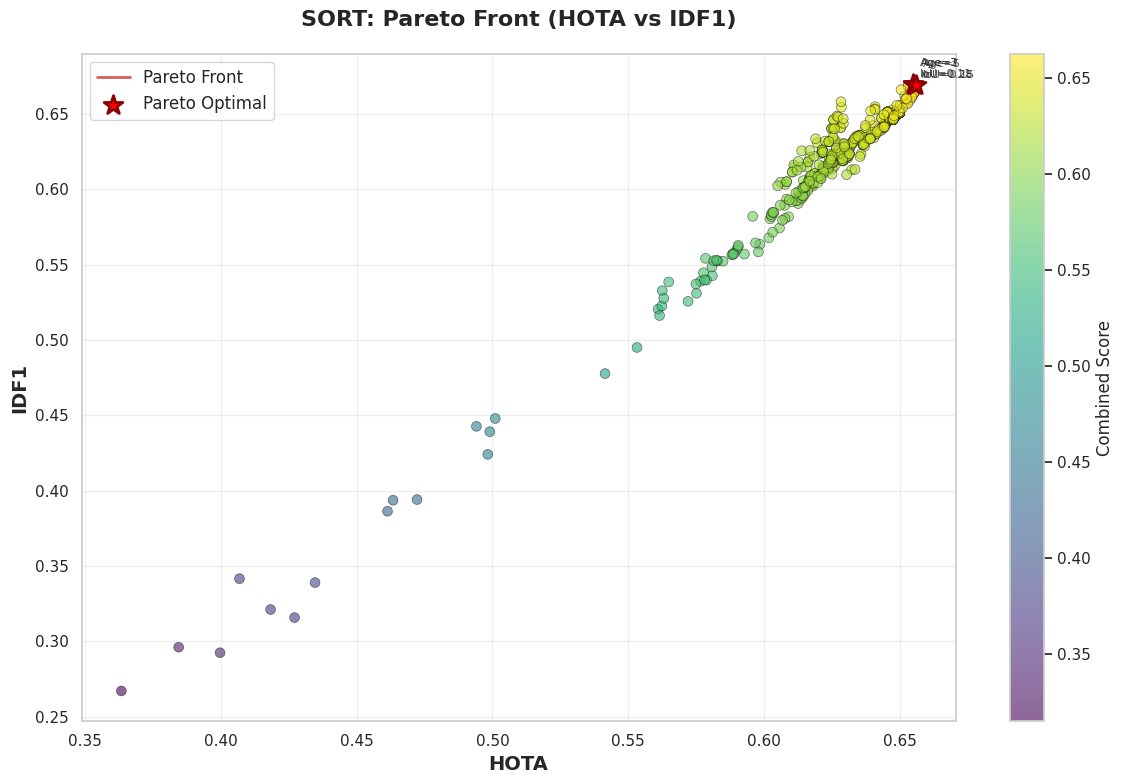

In [42]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all trials
scatter = ax.scatter(df_results['HOTA'], df_results['IDF1'], 
                    c=df_results['Combined'], cmap='viridis', 
                    s=50, alpha=0.6, edgecolors='k', linewidth=0.5)

# Highlight Pareto front
pareto_sorted = pareto_trials.sort_values('HOTA')
ax.plot(pareto_sorted['HOTA'], pareto_sorted['IDF1'], 
        'r-', linewidth=2, label='Pareto Front', zorder=5)
ax.scatter(pareto_trials['HOTA'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', 
          linewidth=2, label='Pareto Optimal', zorder=6)

# Annotate best trials
for idx, row in pareto_trials.head(5).iterrows():
    ax.annotate(f"Age={row['max_age']:.0f}\nIoU={row['iou_threshold']:.2f}", 
                xy=(row['HOTA'], row['IDF1']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

ax.set_xlabel('HOTA', fontsize=14, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=14, fontweight='bold')
ax.set_title('SORT: Pareto Front (HOTA vs IDF1)', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Combined Score', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Interactive 3D Scatter Plots

In [43]:
# 3D plot: iou_threshold vs max_age vs HOTA
df_results['Pareto'] = df_results['is_pareto'].map({True: 'Pareto Optimal', False: 'Regular'})

fig = go.Figure()

regular = df_results[~df_results['is_pareto']]
fig.add_trace(go.Scatter3d(
    x=regular['iou_threshold'],
    y=regular['max_age'],
    z=regular['HOTA'],
    mode='markers',
    name='Regular (HOTA)',
    marker=dict(size=5, color=regular['HOTA'], colorscale='Blues', opacity=0.6, 
                showscale=True, colorbar=dict(x=1.15, title="HOTA")),
    text=[f"IoU: {row['iou_threshold']:.2f}<br>Age: {row['max_age']}<br>Hits: {row['min_hits']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in regular.iterrows()],
    hoverinfo='text'
))

fig.add_trace(go.Scatter3d(
    x=pareto_trials['iou_threshold'],
    y=pareto_trials['max_age'],
    z=pareto_trials['HOTA'],
    mode='markers',
    name='Pareto Optimal',
    marker=dict(size=10, color='red', symbol='diamond', line=dict(color='darkred', width=2)),
    text=[f"IoU: {row['iou_threshold']:.2f}<br>Age: {row['max_age']}<br>Hits: {row['min_hits']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in pareto_trials.iterrows()],
    hoverinfo='text'
))

fig.update_layout(
    title='3D: iou_threshold vs max_age vs HOTA',
    scene=dict(xaxis_title='IoU Threshold', yaxis_title='Max Age', zaxis_title='HOTA',
               camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))),
    width=1000, height=800
)
fig.show()

In [44]:
# 3D plot: iou_threshold vs min_hits vs IDF1
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=regular['iou_threshold'],
    y=regular['min_hits'],
    z=regular['IDF1'],
    mode='markers',
    name='Regular (IDF1)',
    marker=dict(size=5, color=regular['IDF1'], colorscale='Greens', opacity=0.6, 
                showscale=True, colorbar=dict(x=1.15, title="IDF1")),
    text=[f"IoU: {row['iou_threshold']:.2f}<br>Age: {row['max_age']}<br>Hits: {row['min_hits']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in regular.iterrows()],
    hoverinfo='text'
))

fig.add_trace(go.Scatter3d(
    x=pareto_trials['iou_threshold'],
    y=pareto_trials['min_hits'],
    z=pareto_trials['IDF1'],
    mode='markers',
    name='Pareto Optimal',
    marker=dict(size=10, color='red', symbol='diamond', line=dict(color='darkred', width=2)),
    text=[f"IoU: {row['iou_threshold']:.2f}<br>Age: {row['max_age']}<br>Hits: {row['min_hits']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in pareto_trials.iterrows()],
    hoverinfo='text'
))

fig.update_layout(
    title='3D: iou_threshold vs min_hits vs IDF1',
    scene=dict(xaxis_title='IoU Threshold', yaxis_title='Min Hits', zaxis_title='IDF1',
               camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))),
    width=1000, height=800
)
fig.show()

## 7. Hyperparameter vs Metrics Analysis

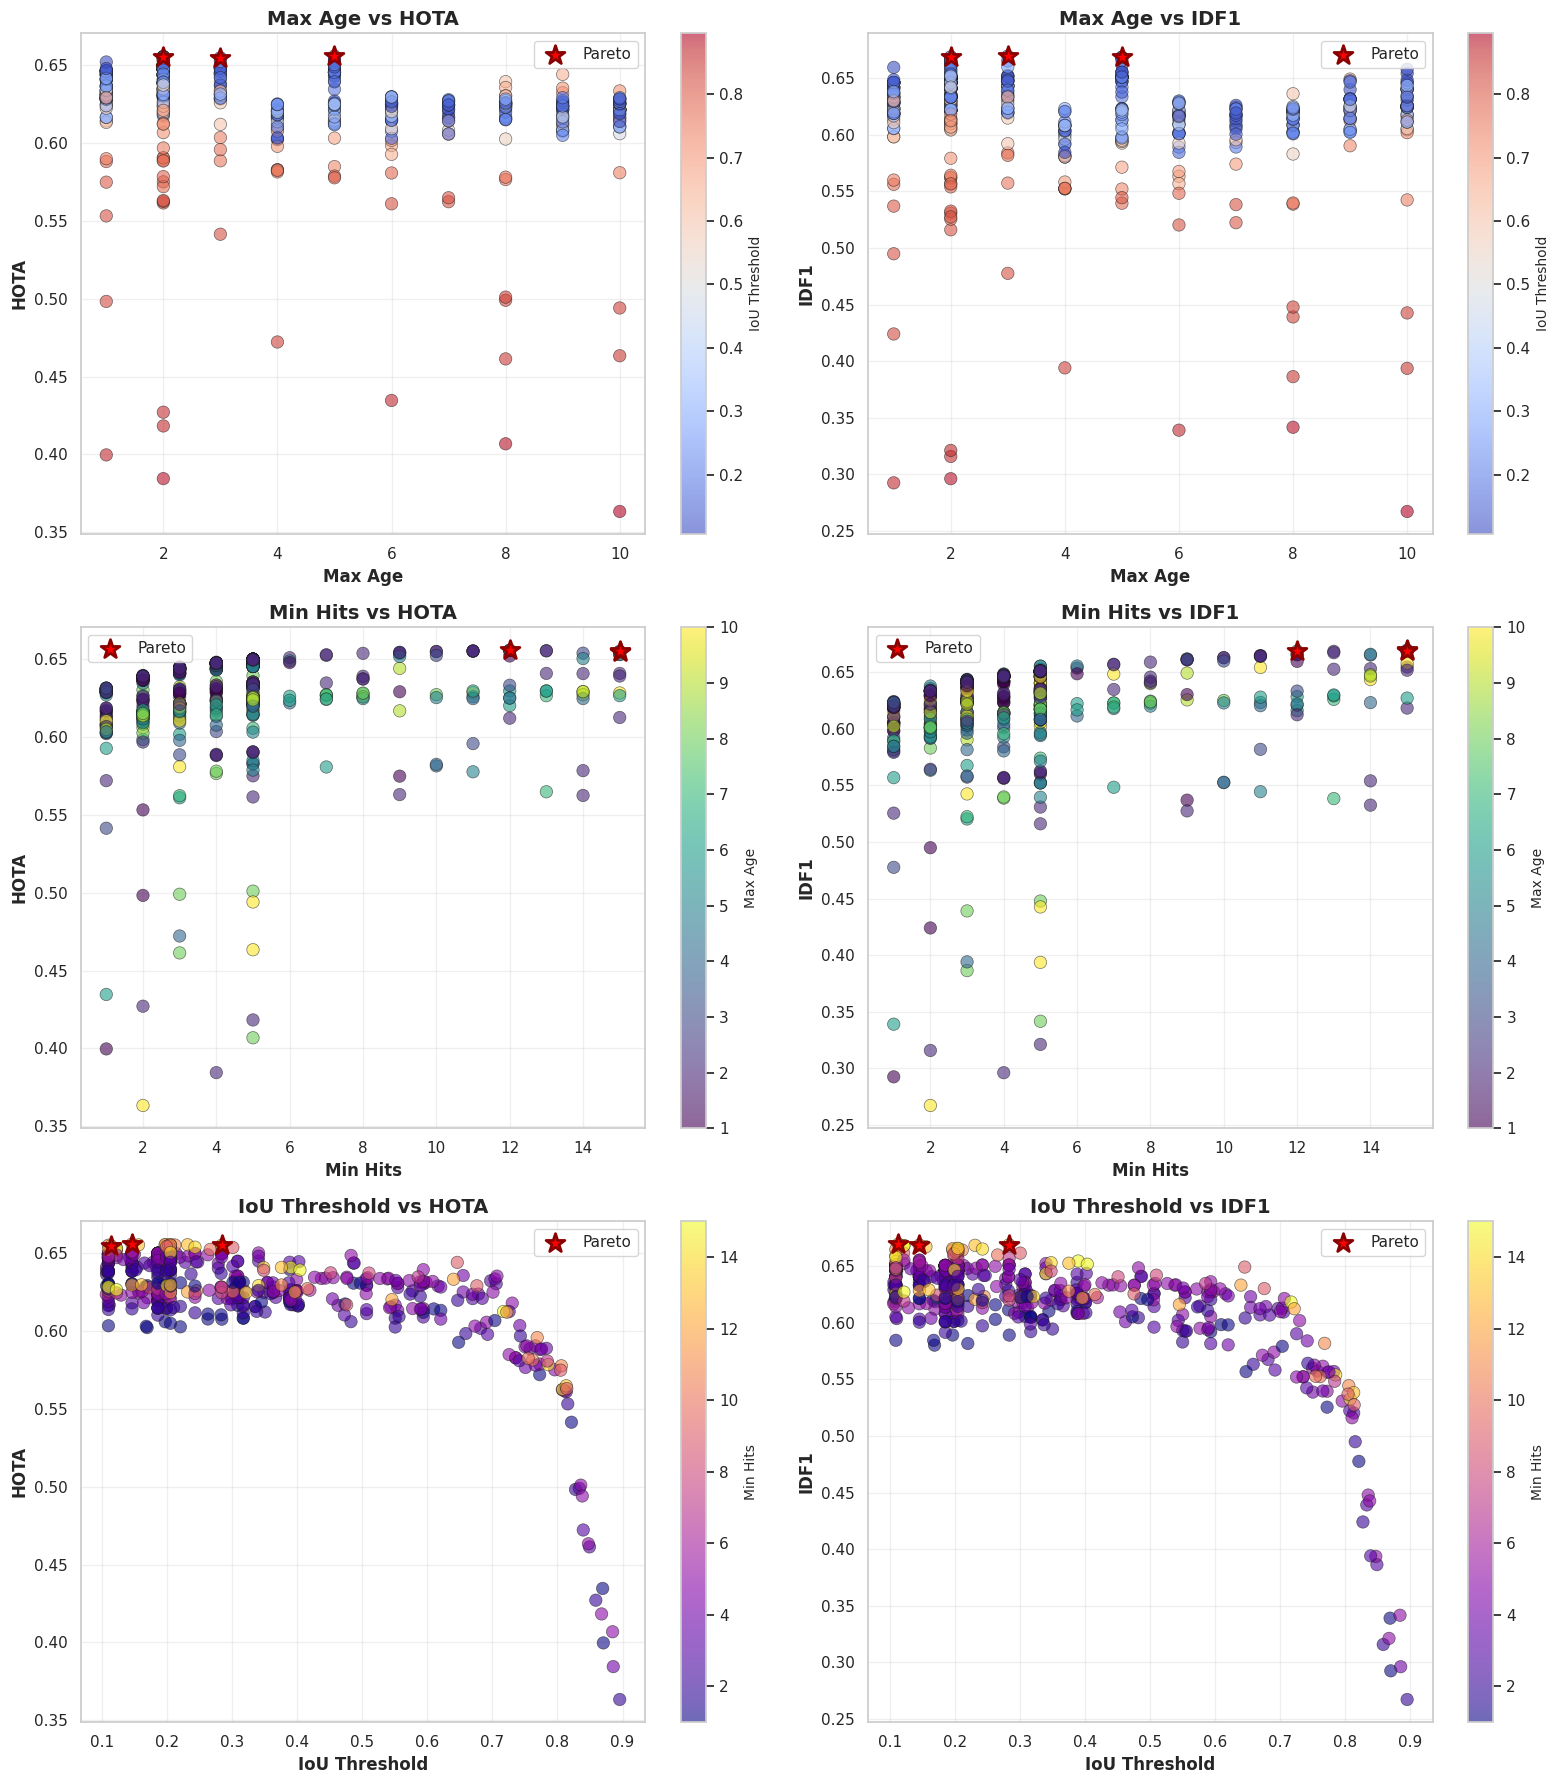

In [45]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Max Age vs HOTA
ax = axes[0, 0]
scatter = ax.scatter(df_results['max_age'], df_results['HOTA'], 
                    c=df_results['iou_threshold'], cmap='coolwarm', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['max_age'], pareto_trials['HOTA'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Max Age', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA', fontsize=12, fontweight='bold')
ax.set_title('Max Age vs HOTA', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('IoU Threshold', fontsize=10)

# Max Age vs IDF1
ax = axes[0, 1]
scatter = ax.scatter(df_results['max_age'], df_results['IDF1'], 
                    c=df_results['iou_threshold'], cmap='coolwarm', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['max_age'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Max Age', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('Max Age vs IDF1', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('IoU Threshold', fontsize=10)

# Min Hits vs HOTA
ax = axes[1, 0]
scatter = ax.scatter(df_results['min_hits'], df_results['HOTA'], 
                    c=df_results['max_age'], cmap='viridis', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['min_hits'], pareto_trials['HOTA'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Min Hits', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA', fontsize=12, fontweight='bold')
ax.set_title('Min Hits vs HOTA', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Max Age', fontsize=10)

# Min Hits vs IDF1
ax = axes[1, 1]
scatter = ax.scatter(df_results['min_hits'], df_results['IDF1'], 
                    c=df_results['max_age'], cmap='viridis', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['min_hits'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Min Hits', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('Min Hits vs IDF1', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Max Age', fontsize=10)

# IoU Threshold vs HOTA
ax = axes[2, 0]
scatter = ax.scatter(df_results['iou_threshold'], df_results['HOTA'], 
                    c=df_results['min_hits'], cmap='plasma', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['iou_threshold'], pareto_trials['HOTA'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('IoU Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA', fontsize=12, fontweight='bold')
ax.set_title('IoU Threshold vs HOTA', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Min Hits', fontsize=10)

# IoU Threshold vs IDF1
ax = axes[2, 1]
scatter = ax.scatter(df_results['iou_threshold'], df_results['IDF1'], 
                    c=df_results['min_hits'], cmap='plasma', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['iou_threshold'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('IoU Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('IoU Threshold vs IDF1', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Min Hits', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Heatmaps

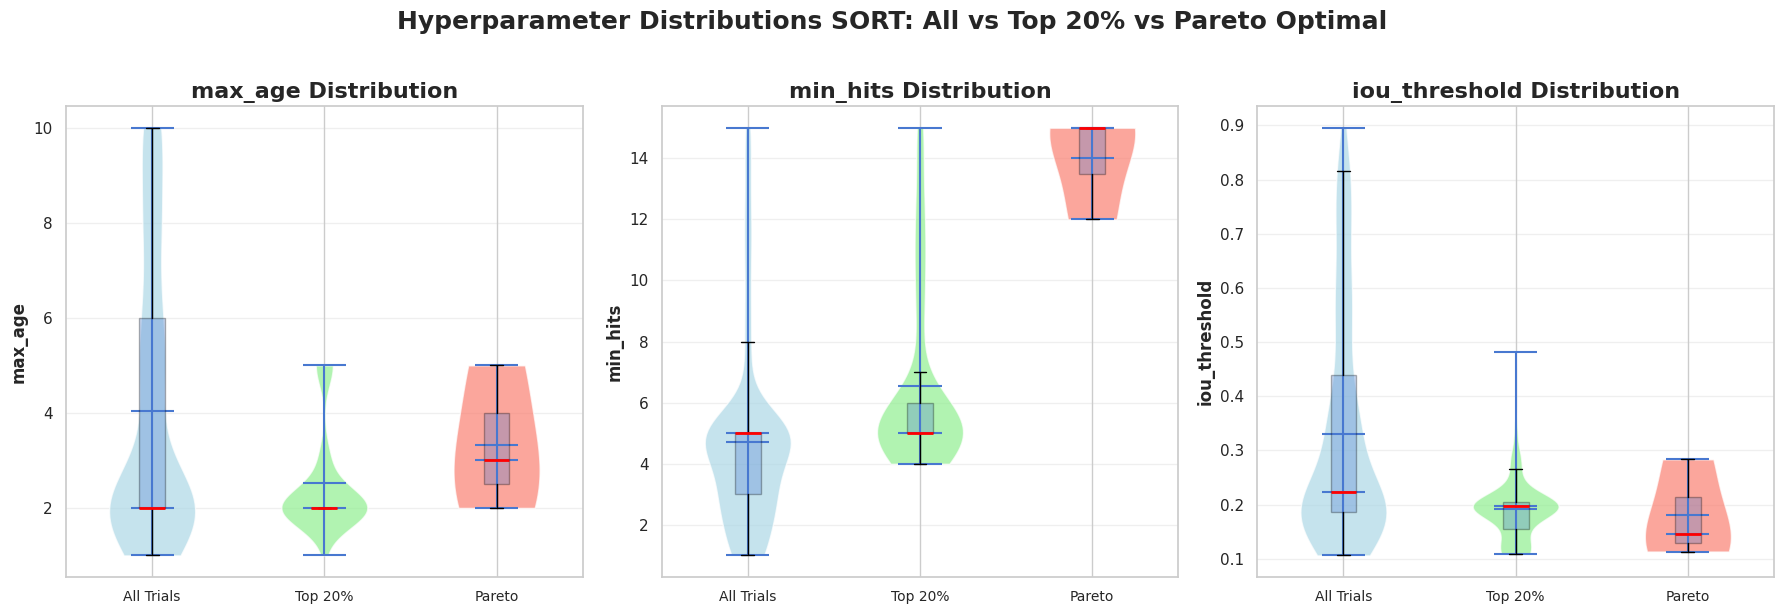

In [52]:
# Violin plots comparing All Trials vs Pareto Optimal vs Top 20% Combined
numerical_params = ['max_age', 'min_hits', 'iou_threshold']
top_20_pct = df_results.nlargest(int(len(df_results)*0.2), 'Combined')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for idx, param in enumerate(numerical_params):
    ax = axes[idx]
    
    # Prepare data for violin plot
    data_to_plot = [
        df_results[param],
        top_20_pct[param],
        pareto_trials[param]
    ]
    
    positions = [1, 2, 3]
    parts = ax.violinplot(data_to_plot, positions=positions, showmeans=True, showmedians=True, showextrema=True)
    
    # Customize colors
    colors = ['lightblue', 'lightgreen', 'salmon']
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    
    # Add box plots on top for better readability
    bp = ax.boxplot(data_to_plot, positions=positions, widths=0.15, 
                     patch_artist=True, showfliers=False,
                     boxprops=dict(alpha=0.3),
                     medianprops=dict(color='red', linewidth=2))
    
    ax.set_xticks(positions)
    ax.set_xticklabels(['All Trials', 'Top 20%', 'Pareto'], fontsize=10)
    ax.set_ylabel(param, fontsize=12, fontweight='bold')
    ax.set_title(f'{param} Distribution', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Hyperparameter Distributions SORT: All vs Top 20% vs Pareto Optimal', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7a. Optimal Hyperparameter Ranges - Violin Plots

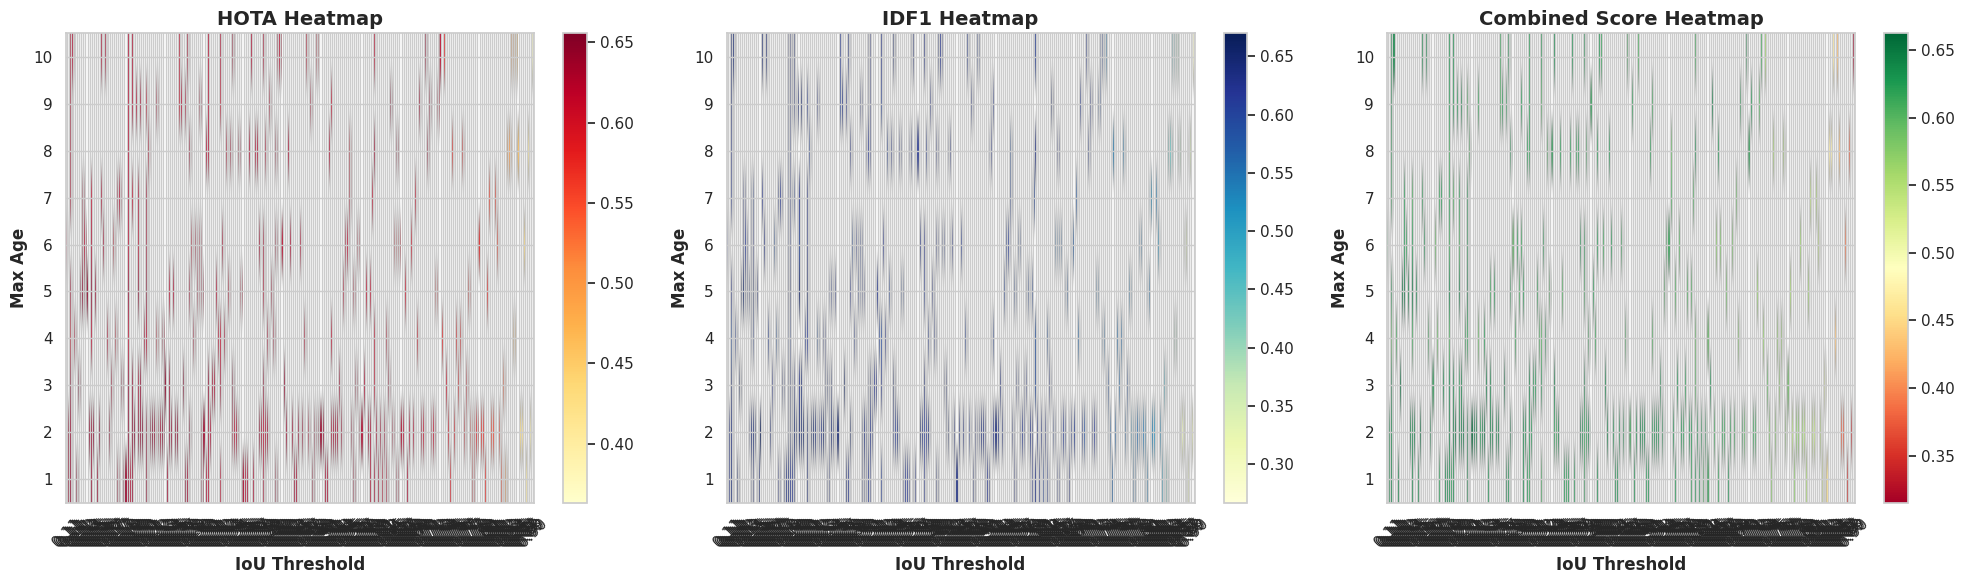

In [47]:
# Create pivot tables for heatmaps
pivot_hota = df_results.pivot_table(
    index='max_age', 
    columns='iou_threshold', 
    values='HOTA', 
    aggfunc='mean'
)

pivot_idf1 = df_results.pivot_table(
    index='max_age', 
    columns='iou_threshold', 
    values='IDF1', 
    aggfunc='mean'
)

pivot_combined = df_results.pivot_table(
    index='max_age', 
    columns='iou_threshold', 
    values='Combined', 
    aggfunc='mean'
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# HOTA Heatmap
im1 = axes[0].imshow(pivot_hota, cmap='YlOrRd', aspect='auto', origin='lower')
axes[0].set_xticks(range(len(pivot_hota.columns)))
axes[0].set_xticklabels([f'{x:.2f}' for x in pivot_hota.columns], rotation=45)
axes[0].set_yticks(range(len(pivot_hota.index)))
axes[0].set_yticklabels([f'{int(y)}' for y in pivot_hota.index])
axes[0].set_xlabel('IoU Threshold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Max Age', fontsize=12, fontweight='bold')
axes[0].set_title('HOTA Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# IDF1 Heatmap
im2 = axes[1].imshow(pivot_idf1, cmap='YlGnBu', aspect='auto', origin='lower')
axes[1].set_xticks(range(len(pivot_idf1.columns)))
axes[1].set_xticklabels([f'{x:.2f}' for x in pivot_idf1.columns], rotation=45)
axes[1].set_yticks(range(len(pivot_idf1.index)))
axes[1].set_yticklabels([f'{int(y)}' for y in pivot_idf1.index])
axes[1].set_xlabel('IoU Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Max Age', fontsize=12, fontweight='bold')
axes[1].set_title('IDF1 Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1])

# Combined Heatmap
im3 = axes[2].imshow(pivot_combined, cmap='RdYlGn', aspect='auto', origin='lower')
axes[2].set_xticks(range(len(pivot_combined.columns)))
axes[2].set_xticklabels([f'{x:.2f}' for x in pivot_combined.columns], rotation=45)
axes[2].set_yticks(range(len(pivot_combined.index)))
axes[2].set_yticklabels([f'{int(y)}' for y in pivot_combined.index])
axes[2].set_xlabel('IoU Threshold', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Max Age', fontsize=12, fontweight='bold')
axes[2].set_title('Combined Score Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

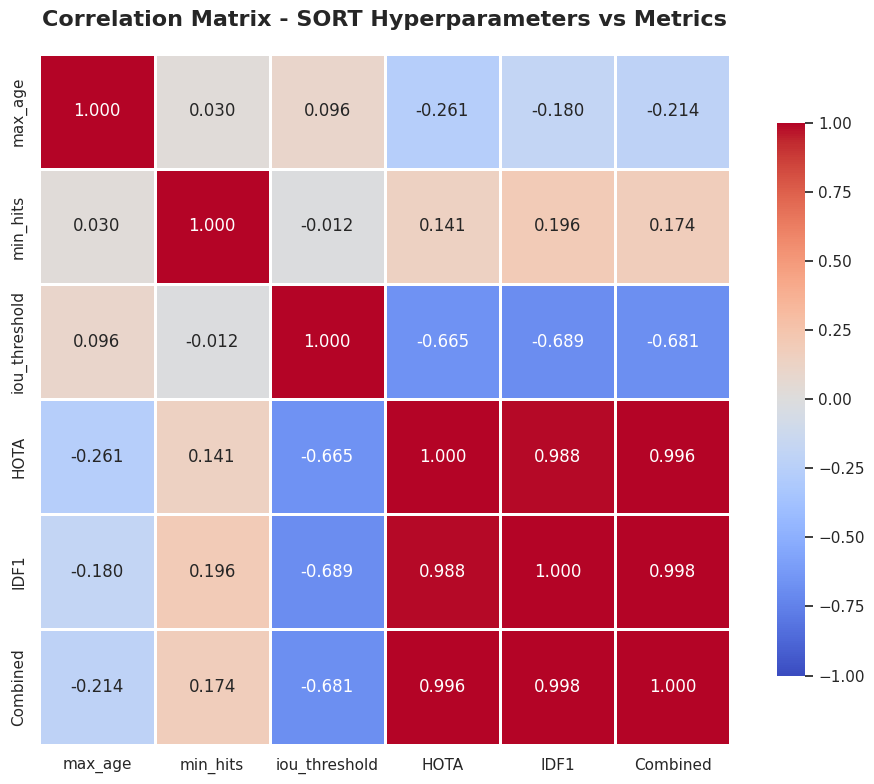


Key correlations:
  max_age vs HOTA: -0.2609
  max_age vs IDF1: -0.1802
  min_hits vs HOTA: 0.1408
  min_hits vs IDF1: 0.1961
  iou_threshold vs HOTA: -0.6646
  iou_threshold vs IDF1: -0.6893
  HOTA vs IDF1: 0.9882


In [48]:
# Correlation matrix
correlation_cols = ['max_age', 'min_hits', 'iou_threshold', 'HOTA', 'IDF1', 'Combined']
correlation_matrix = df_results[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix - SORT Hyperparameters vs Metrics', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKey correlations:")
print(f"  max_age vs HOTA: {correlation_matrix.loc['max_age', 'HOTA']:.4f}")
print(f"  max_age vs IDF1: {correlation_matrix.loc['max_age', 'IDF1']:.4f}")
print(f"  min_hits vs HOTA: {correlation_matrix.loc['min_hits', 'HOTA']:.4f}")
print(f"  min_hits vs IDF1: {correlation_matrix.loc['min_hits', 'IDF1']:.4f}")
print(f"  iou_threshold vs HOTA: {correlation_matrix.loc['iou_threshold', 'HOTA']:.4f}")
print(f"  iou_threshold vs IDF1: {correlation_matrix.loc['iou_threshold', 'IDF1']:.4f}")
print(f"  HOTA vs IDF1: {correlation_matrix.loc['HOTA', 'IDF1']:.4f}")

## 10. Distribution Analysis

/tmp/ipykernel_66992/2997671096.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



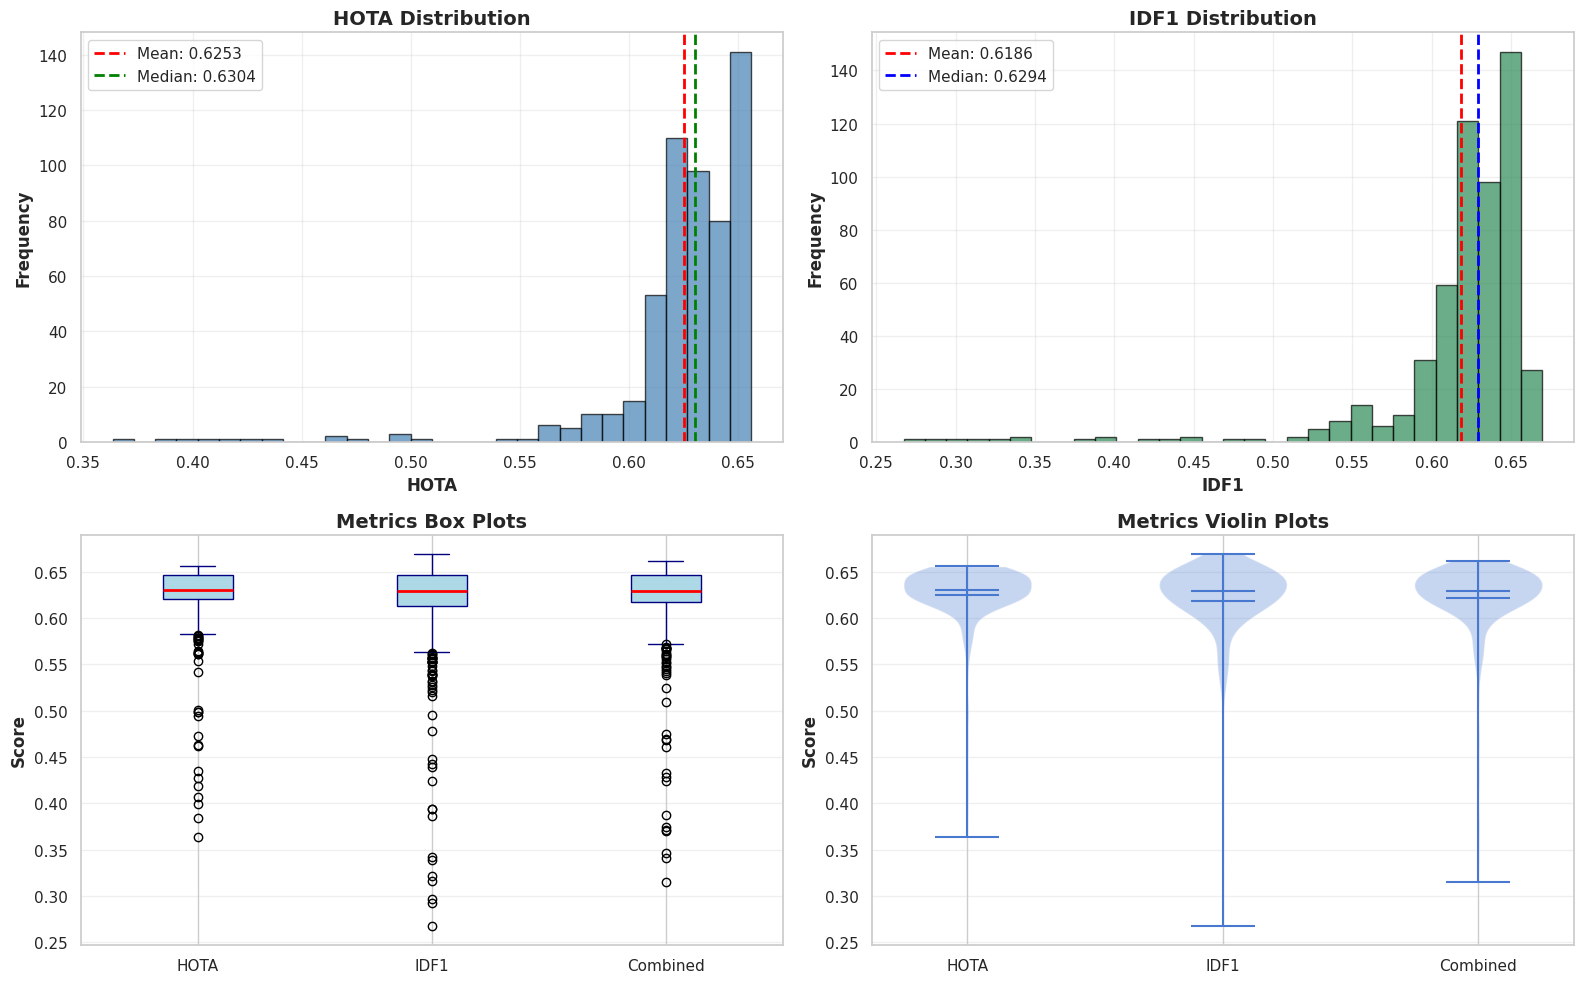

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# HOTA distribution
axes[0, 0].hist(df_results['HOTA'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_results['HOTA'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {df_results["HOTA"].mean():.4f}')
axes[0, 0].axvline(df_results['HOTA'].median(), color='green', linestyle='--', linewidth=2, 
                   label=f'Median: {df_results["HOTA"].median():.4f}')
axes[0, 0].set_xlabel('HOTA', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('HOTA Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# IDF1 distribution
axes[0, 1].hist(df_results['IDF1'], bins=30, edgecolor='black', alpha=0.7, color='seagreen')
axes[0, 1].axvline(df_results['IDF1'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {df_results["IDF1"].mean():.4f}')
axes[0, 1].axvline(df_results['IDF1'].median(), color='blue', linestyle='--', linewidth=2, 
                   label=f'Median: {df_results["IDF1"].median():.4f}')
axes[0, 1].set_xlabel('IDF1', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('IDF1 Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plots
box_data = [df_results['HOTA'], df_results['IDF1'], df_results['Combined']]
axes[1, 0].boxplot(box_data, labels=['HOTA', 'IDF1', 'Combined'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='navy'),
                   capprops=dict(color='navy'))
axes[1, 0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Metrics Box Plots', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Violin plots
parts = axes[1, 1].violinplot(box_data, positions=[1, 2, 3], showmeans=True, showmedians=True)
axes[1, 1].set_xticks([1, 2, 3])
axes[1, 1].set_xticklabels(['HOTA', 'IDF1', 'Combined'])
axes[1, 1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Metrics Violin Plots', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 11. Top Configurations

In [50]:
print("="*80)
print("TOP 10 CONFIGURATIONS")
print("="*80)

print("\nBy HOTA:")
top_hota = df_results.nlargest(10, 'HOTA')[['trial_id', 'max_age', 'min_hits', 'iou_threshold', 'HOTA', 'IDF1', 'Combined']]
print(top_hota.to_string(index=False))

print("\n" + "-"*80)
print("\nBy IDF1:")
top_idf1 = df_results.nlargest(10, 'IDF1')[['trial_id', 'max_age', 'min_hits', 'iou_threshold', 'HOTA', 'IDF1', 'Combined']]
print(top_idf1.to_string(index=False))

print("\n" + "-"*80)
print("\nBy Combined Score:")
top_combined = df_results.nlargest(10, 'Combined')[['trial_id', 'max_age', 'min_hits', 'iou_threshold', 'HOTA', 'IDF1', 'Combined']]
print(top_combined.to_string(index=False))

TOP 10 CONFIGURATIONS

By HOTA:
 trial_id  max_age  min_hits  iou_threshold     HOTA     IDF1  Combined
     1892      5.0      12.0       0.145814 0.655900 0.668814  0.662357
     1817      2.0      12.0       0.205002 0.655643 0.665663  0.660653
     1844      2.0      12.0       0.196970 0.655643 0.665663  0.660653
     1800      2.0      13.0       0.231302 0.655529 0.668594  0.662061
     1827      2.0      13.0       0.155856 0.655403 0.667362  0.661383
     1784      2.0      11.0       0.196970 0.655334 0.664358  0.659846
     1873      2.0      11.0       0.205002 0.655334 0.664358  0.659846
     1843      2.0      11.0       0.211716 0.655300 0.664358  0.659829
     1818      2.0      11.0       0.109633 0.655183 0.664870  0.660026
     1869      2.0      15.0       0.283720 0.655117 0.669065  0.662091

--------------------------------------------------------------------------------

By IDF1:
 trial_id  max_age  min_hits  iou_threshold     HOTA     IDF1  Combined
     1824   

## 12. Summary and Recommendations

In [51]:
print("="*80)
print("SORT - SUMMARY AND RECOMMENDATIONS")
print("="*80)

best_combined_trial = df_results.loc[df_results['Combined'].idxmax()]

print("\n🏆 RECOMMENDED CONFIGURATION (Best Combined Score):")
print(f"  - Max Age: {int(best_combined_trial['max_age'])}")
print(f"  - Min Hits: {int(best_combined_trial['min_hits'])}")
print(f"  - IoU Threshold: {best_combined_trial['iou_threshold']:.4f}")
print(f"  - HOTA: {best_combined_trial['HOTA']:.4f}")
print(f"  - IDF1: {best_combined_trial['IDF1']:.4f}")
print(f"  - Combined: {best_combined_trial['Combined']:.4f}")

print("\n📊 Key Findings:")
print(f"  • Total trials evaluated: {len(df_results)}")
print(f"  • Pareto optimal solutions: {len(pareto_trials)}")
print(f"  • HOTA range: [{df_results['HOTA'].min():.4f}, {df_results['HOTA'].max():.4f}]")
print(f"  • IDF1 range: [{df_results['IDF1'].min():.4f}, {df_results['IDF1'].max():.4f}]")

print("\n🔍 Parameter Insights:")
hota_top20_pct = df_results.nlargest(int(len(df_results)*0.2), 'HOTA')
idf1_top20_pct = df_results.nlargest(int(len(df_results)*0.2), 'IDF1')

print(f"  • Best Max Age range (top 20% HOTA): [{hota_top20_pct['max_age'].min():.0f}, {hota_top20_pct['max_age'].max():.0f}]")
print(f"  • Best Min Hits range (top 20% HOTA): [{hota_top20_pct['min_hits'].min():.0f}, {hota_top20_pct['min_hits'].max():.0f}]")
print(f"  • Best IoU Threshold range (top 20% HOTA): [{hota_top20_pct['iou_threshold'].min():.2f}, {hota_top20_pct['iou_threshold'].max():.2f}]")

print("\n✅ Analysis Complete!")

SORT - SUMMARY AND RECOMMENDATIONS

🏆 RECOMMENDED CONFIGURATION (Best Combined Score):
  - Max Age: 5
  - Min Hits: 12
  - IoU Threshold: 0.1458
  - HOTA: 0.6559
  - IDF1: 0.6688
  - Combined: 0.6624

📊 Key Findings:
  • Total trials evaluated: 544
  • Pareto optimal solutions: 3
  • HOTA range: [0.3634, 0.6559]
  • IDF1 range: [0.2672, 0.6697]

🔍 Parameter Insights:
  • Best Max Age range (top 20% HOTA): [1, 5]
  • Best Min Hits range (top 20% HOTA): [4, 15]
  • Best IoU Threshold range (top 20% HOTA): [0.11, 0.48]

✅ Analysis Complete!
